# 05: Robustness and Sensitivity for Discovery Quality Mediation

The previous notebook estimated the main discovery-quality mediation result: high discovery exposure was associated with higher future interaction volume, while the satisfaction-depth mediated pathway was small and slightly negative for the primary interaction-count outcome.

This notebook asks whether that story is fragile.

A good causal project notebook should not stop after one preferred specification. It should ask what happens when reasonable choices change:

- Does the result survive different high-discovery thresholds?
- Does it depend on one particular satisfaction mediator definition?
- Does it look similar for future play time and active days?
- Does it change under weighted versus unweighted models?
- Does it depend on including a treatment-mediator interaction?
- Is the result mostly a calendar-time or pre-period activity artifact?

The goal is not to prove the observational design is perfect. The goal is to show what is stable, what is sensitive, and what a careful reader should trust only with caveats.

<!-- dataset-experiment-context -->
## Dataset and Mediation Design Context

This project uses KuaiRec interaction logs and metadata organized into active user-day records. The workflow constructs discovery-breadth, satisfaction-depth, quality-adjusted discovery, and shallow-click-pressure metrics from logged viewing behavior.

This is a real observational recommendation log, not a randomized mediation experiment. The treatment is high discovery-breadth exposure, the mediator is same-day satisfaction depth, and the primary outcome is future seven-day interactions.

The project asks whether discovery exposure relates to future value directly, indirectly through satisfaction depth, or both. Because mediation in observational logs requires strong assumptions, the notebooks emphasize metric construction, temporal ordering, overlap, placebo-style checks, robustness across definitions, and model sensitivity.

**Role of this notebook.** This notebook checks how the mediation conclusions change across treatment thresholds, mediator definitions, outcomes, controls, and placebo-style tests.

<!-- mathematical-setup -->

## Mathematical Setup

Robustness analysis compares mediation estimates across defensible design choices. If \(m\) indexes mediator definitions, thresholds, models, or outcomes, the notebook studies

$$
\left\{\widehat{\operatorname{NIE}}(m),\widehat{\operatorname{NDE}}(m),\widehat{\operatorname{TE}}(m):m\in\mathcal{M}\right\}.
$$

A simple stability summary is the spread of an effect component across choices:

$$
\operatorname{spread}(\widehat\theta)=\max_{m\in\mathcal{M}}\widehat\theta(m)-\min_{m\in\mathcal{M}}\widehat\theta(m),
\qquad
\theta\in\{\operatorname{NIE},\operatorname{NDE},\operatorname{TE}\}.
$$

A robust mediation story should keep its sign and broad magnitude across reasonable choices. If the indirect effect appears for only one metric definition or one model family, the result should be framed as exploratory.


#### 1. Load Libraries and Paths

This cell imports the libraries used for robustness modeling and plotting. It also defines all inputs from the previous notebooks and all outputs created here.

In [1]:
# Load libraries and paths.
from pathlib import Path
import os
import warnings

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "discovery_quality_mediation"
WRITEUP_DIR = NOTEBOOK_DIR / "writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_PANEL_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_analysis_panel.parquet"
EFFECT_SUMMARY_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_effect_summary.csv"
ASSUMPTION_CHECKS_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_assumption_checks.csv"

THRESHOLD_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_robustness_thresholds.csv"
MEDIATOR_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_robustness_mediators.csv"
MODEL_SENSITIVITY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_model_sensitivity.csv"
CONTINUOUS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_continuous_score_sensitivity.csv"
PLACEBO_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_placebo_checks.csv"
ROBUSTNESS_SUMMARY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_robustness_summary.csv"
LIMITATIONS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_limitations.csv"

The thread limits keep the notebook predictable on a laptop or shared environment. This notebook runs many small linear models, so it does not need aggressive parallel math libraries.

#### 2. Load the Analysis Panel and Main Results

This cell loads the mediation analysis panel and the effect summary from notebook 04. The effect summary is the reference point for every stress test in this notebook.

In [2]:
analysis_panel = pd.read_parquet(ANALYSIS_PANEL_INPUT)
effect_summary = pd.read_csv(EFFECT_SUMMARY_INPUT)
assumption_checks = pd.read_csv(ASSUMPTION_CHECKS_INPUT)

load_summary = pd.DataFrame(
    {
        "artifact": ["analysis_panel", "effect_summary", "assumption_checks"],
        "rows": [len(analysis_panel), len(effect_summary), len(assumption_checks)],
        "columns": [analysis_panel.shape[1], effect_summary.shape[1], assumption_checks.shape[1]],
    }
)

main_primary = effect_summary.query(
    "outcome == 'Y_future_interactions' and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).copy()

display(load_summary)
display(main_primary[["outcome_label", "estimand", "estimate", "ci_95_lower", "ci_95_upper", "relative_effect"]].round(4))

,artifact,rows,columns
0,analysis_panel,8199,103
1,effect_summary,21,12
2,assumption_checks,6,5


,outcome_label,estimand,estimate,ci_95_lower,ci_95_upper,relative_effect
2,Future 7-day interactions,gcomp_total_effect,37.2781,32.2444,42.8135,0.1152
3,Future 7-day interactions,natural_direct_effect,38.5858,33.3634,43.7154,0.1192
4,Future 7-day interactions,natural_indirect_effect,-1.3077,-2.3047,-0.4290,-0.0036


The main result is the anchor: a positive total effect on future interactions, a direct effect of similar size, and a small negative indirect pathway through the satisfaction-depth metric. The rest of this notebook checks how stable that pattern is.

#### 3. Define Outcomes, Mediators, and Controls

This cell defines the variable sets used across robustness checks. The rich controls mirror earlier notebooks. The simple controls are intentionally smaller and help answer whether the result is only produced by a large adjustment set.

In [3]:
# Define outcomes, mediators, and controls.
PRIMARY_OUTCOME = "Y_future_interactions"
OUTCOME_COLUMNS = ["Y_future_interactions", "Y_future_active_days", "Y_future_play_hours"]
OUTCOME_LABELS = {
    "Y_future_interactions": "Future 7-day interactions",
    "Y_future_active_days": "Future 7-day active days",
    "Y_future_play_hours": "Future 7-day play hours",
}
BASE_TREATMENT = "A_high_discovery"
BASE_MEDIATOR = "M_satisfaction_depth"
DISCOVERY_SCORE = "discovery_breadth_score"

base_numeric_covariates = [
    "calendar_day_index",
    "lag_1_active_day",
    "prior_3day_active_day",
    "lag_1_interactions",
    "prior_3day_interactions",
    "lag_1_total_play_duration_sec",
    "prior_3day_total_play_duration_sec",
    "lag_1_valid_play_share",
    "prior_3day_valid_play_share",
    "lag_1_high_satisfaction_share",
    "prior_3day_high_satisfaction_share",
    "lag_1_discovery_candidate_share",
    "prior_3day_discovery_candidate_share",
    "recent_activity_score",
    "register_days",
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "is_lowactive_period",
    "is_live_streamer",
    "is_video_author",
]
profile_onehot_covariates = [col for col in analysis_panel.columns if col.startswith("onehot_feat")]
rich_numeric_covariates = [col for col in base_numeric_covariates + profile_onehot_covariates if col in analysis_panel.columns]
rich_categorical_covariates = [
    col
    for col in [
        "user_active_degree",
        "follow_user_num_range",
        "fans_user_num_range",
        "friend_user_num_range",
        "register_days_range",
    ]
    if col in analysis_panel.columns
]

simple_numeric_covariates = [
    col
    for col in [
        "calendar_day_index",
        "lag_1_interactions",
        "prior_3day_interactions",
        "prior_3day_high_satisfaction_share",
        "prior_3day_discovery_candidate_share",
        "register_days",
    ]
    if col in analysis_panel.columns
]
simple_categorical_covariates = ["user_active_degree"] if "user_active_degree" in analysis_panel.columns else []

mediator_candidates = {
    "composite_satisfaction_depth": "M_satisfaction_depth",
    "high_watch_ratio_share": "high_satisfaction_share",
    "valid_play_share": "valid_play_share",
    "average_satisfaction_score": "avg_satisfaction_score",
    "completion_or_rewatch_share": "complete_or_rewatch_share",
}

control_summary = pd.DataFrame(
    {
        "control_set": ["rich", "simple"],
        "numeric_covariates": [len(rich_numeric_covariates), len(simple_numeric_covariates)],
        "categorical_covariates": [len(rich_categorical_covariates), len(simple_categorical_covariates)],
    }
)
mediator_summary = pd.DataFrame(
    {"mediator_label": list(mediator_candidates.keys()), "column": list(mediator_candidates.values())}
)

display(control_summary)
display(mediator_summary)

,control_set,numeric_covariates,categorical_covariates
0,rich,39,5
1,simple,6,1


,mediator_label,column
0,composite_satisfaction_depth,M_satisfaction_depth
1,high_watch_ratio_share,high_satisfaction_share
2,valid_play_share,valid_play_share
3,average_satisfaction_score,avg_satisfaction_score
4,completion_or_rewatch_share,complete_or_rewatch_share


The mediator candidates are all same-day quality signals, but they do not measure exactly the same thing. If the indirect pathway changes sign or size across these mediators, that tells us the mediation result is sensitive to how satisfaction is measured.

#### 4. Build Reusable Estimation Helpers

This cell defines the robustness estimator. It follows the same g-computation logic as notebook 04 but adds options for treatment definitions, mediator definitions, control sets, weighting, and treatment-mediator interactions.

In [4]:
# Build reusable estimation helpers.
def build_covariate_matrix(frame, numeric_cols, categorical_cols):
    """
    Build a numeric covariate matrix for mediation adjustment.
    
    Idea
    ----
    The helper combines numeric and categorical pre-treatment covariates into a model matrix used by treatment, mediator, and outcome models.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix aligned with the input frame.
    """
    numeric = frame[numeric_cols].copy()
    for col in numeric.columns:
        numeric[col] = pd.to_numeric(numeric[col], errors="coerce")
        numeric[col] = numeric[col].fillna(numeric[col].median())

    if categorical_cols:
        categorical = frame[categorical_cols].copy()
        for col in categorical.columns:
            categorical[col] = categorical[col].astype("string").fillna("missing")
        encoded = pd.get_dummies(categorical, drop_first=True, dtype=float)
        design = pd.concat([numeric, encoded], axis=1)
    else:
        design = numeric

    design = design.loc[:, design.nunique(dropna=False) > 1]
    return design.astype(float)


def make_treatment_design(covariates, treatment_values, treatment_col):
    """
    Create a treatment-design matrix for a named treatment column.
    
    Idea
    ----
    The helper standardizes how treatment and covariates enter the robustness mediation models.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    treatment_values : object
        Counterfactual or observed treatment values to place in the design matrix.
    treatment_col : object
        Column indicating treatment or exposure status.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix containing covariates and the requested treatment column.
    """
    design = covariates.copy()
    design.insert(0, treatment_col, np.asarray(treatment_values, dtype=float))
    return design


def make_outcome_design(covariates, treatment_values, mediator_values, treatment_col, mediator_col, include_interaction=True):
    """
    Create an outcome-design matrix for robustness mediation models.
    
    Idea
    ----
    The helper controls whether treatment-mediator interactions are included when testing sensitivity of the direct and indirect effects.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    treatment_values : object
        Counterfactual or observed treatment values to place in the design matrix.
    mediator_values : object
        Mediator values to place in the outcome design matrix.
    treatment_col : object
        Column indicating treatment or exposure status.
    mediator_col : object
        Mediator column for the mediation specification.
    include_interaction : object
        Whether to include treatment-mediator interactions.
    
    Returns
    -------
    pandas.DataFrame
        Outcome-model design matrix for one robustness specification.
    """
    treatment_array = np.asarray(treatment_values, dtype=float)
    mediator_array = np.asarray(mediator_values, dtype=float)
    design = covariates.copy()
    if include_interaction:
        design.insert(0, "A_x_M", treatment_array * mediator_array)
    design.insert(0, mediator_col, mediator_array)
    design.insert(0, treatment_col, treatment_array)
    return design


def estimate_stabilized_weights(frame, treatment_col, covariates):
    """
    Estimate stabilized weights for a binary mediation treatment.
    
    Idea
    ----
    The helper models treatment assignment from pre-treatment covariates and converts propensities into weights for robustness checks.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    covariates : object
        Project-specific input named `covariates` used by this helper.
    
    Returns
    -------
    pandas.Series
        Stabilized treatment weights aligned with the input frame.
    """
    treatment = frame[treatment_col].astype(int).to_numpy()
    treatment_rate = treatment.mean()
    if treatment_rate <= 0 or treatment_rate >= 1:
        return np.ones(len(frame)), pd.DataFrame([{"diagnostic": "degenerate_treatment", "value": 1.0}])

    propensity_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, solver="lbfgs"),
    )
    propensity_model.fit(covariates, treatment)
    propensity = propensity_model.predict_proba(covariates)[:, 1].clip(0.02, 0.98)
    weights = np.where(treatment == 1, treatment_rate / propensity, (1 - treatment_rate) / (1 - propensity))
    cap = np.quantile(weights, 0.99)
    weights = np.clip(weights, None, cap)
    ess = weights.sum() ** 2 / np.square(weights).sum()

    diagnostics = pd.DataFrame(
        [
            {"diagnostic": "treatment_rate", "value": treatment_rate},
            {"diagnostic": "propensity_p05", "value": np.quantile(propensity, 0.05)},
            {"diagnostic": "propensity_p95", "value": np.quantile(propensity, 0.95)},
            {"diagnostic": "weight_max", "value": weights.max()},
            {"diagnostic": "effective_sample_size", "value": ess},
        ]
    )
    return weights, diagnostics


def average(values):
    """
    Compute a plain average while preserving the mediation API.
    
    Idea
    ----
    The helper keeps effect calculations readable in specifications where no weights are supplied.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    
    Returns
    -------
    float
        Arithmetic mean of the supplied values.
    """
    return float(np.mean(np.asarray(values, dtype=float)))


def estimate_binary_mediation_spec(
    frame,
    treatment_col,
    mediator_col,
    outcome_col,
    numeric_cols,
    categorical_cols,
    spec_name,
    use_weights=True,
    include_interaction=True,
):
    """
    Estimate one binary-treatment mediation robustness specification.
    
    Idea
    ----
    The function rebuilds the treatment, mediator, and outcome models for a chosen treatment definition, mediator definition, outcome, covariate set, and weighting rule.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    mediator_col : object
        Mediator column for the mediation specification.
    outcome_col : object
        Outcome column used in the estimator.
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    spec_name : object
        Readable name for the robustness specification.
    use_weights : object
        Whether to use stabilized weights in the estimate.
    include_interaction : object
        Whether to include treatment-mediator interactions.
    
    Returns
    -------
    pandas.DataFrame
        Direct, indirect, total, and controlled-direct effect estimates for the specification.
    """
    working = frame.copy().reset_index(drop=True)
    covariates = build_covariate_matrix(working, numeric_cols, categorical_cols)
    A = working[treatment_col].astype(float).to_numpy()
    M = working[mediator_col].astype(float).to_numpy()
    Y = working[outcome_col].astype(float).to_numpy()

    if use_weights:
        weights, weight_diagnostics = estimate_stabilized_weights(working, treatment_col, covariates)
    else:
        weights = None
        weight_diagnostics = pd.DataFrame(
            [
                {"diagnostic": "treatment_rate", "value": A.mean()},
                {"diagnostic": "effective_sample_size", "value": len(working)},
            ]
        )

    mediator_X = make_treatment_design(covariates, A, treatment_col)
    mediator_model = LinearRegression().fit(mediator_X, M, sample_weight=weights)
    M0 = mediator_model.predict(make_treatment_design(covariates, np.zeros(len(working)), treatment_col)).clip(0, 1)
    M1 = mediator_model.predict(make_treatment_design(covariates, np.ones(len(working)), treatment_col)).clip(0, 1)

    outcome_X = make_outcome_design(covariates, A, M, treatment_col, mediator_col, include_interaction=include_interaction)
    outcome_model = LinearRegression().fit(outcome_X, Y, sample_weight=weights)

    y_0_m0 = outcome_model.predict(make_outcome_design(covariates, np.zeros(len(working)), M0, treatment_col, mediator_col, include_interaction=include_interaction))
    y_1_m0 = outcome_model.predict(make_outcome_design(covariates, np.ones(len(working)), M0, treatment_col, mediator_col, include_interaction=include_interaction))
    y_1_m1 = outcome_model.predict(make_outcome_design(covariates, np.ones(len(working)), M1, treatment_col, mediator_col, include_interaction=include_interaction))

    raw_high = working.loc[working[treatment_col].eq(1), outcome_col].mean()
    raw_low = working.loc[working[treatment_col].eq(0), outcome_col].mean()
    baseline_mean = average(y_0_m0)
    total_effect = average(y_1_m1 - y_0_m0)
    direct_effect = average(y_1_m0 - y_0_m0)
    indirect_effect = average(y_1_m1 - y_1_m0)
    mediator_shift = average(M1 - M0)

    result = {
        "spec_name": spec_name,
        "treatment_col": treatment_col,
        "mediator_col": mediator_col,
        "outcome": outcome_col,
        "outcome_label": OUTCOME_LABELS.get(outcome_col, outcome_col),
        "treatment_rate": A.mean(),
        "raw_high_minus_lower": raw_high - raw_low,
        "gcomp_total_effect": total_effect,
        "natural_direct_effect": direct_effect,
        "natural_indirect_effect": indirect_effect,
        "mediator_shift": mediator_shift,
        "proportion_mediated": indirect_effect / total_effect if not np.isclose(total_effect, 0) else np.nan,
        "reference_mean": baseline_mean,
        "relative_total_effect": total_effect / baseline_mean if not np.isclose(baseline_mean, 0) else np.nan,
        "uses_weights": use_weights,
        "include_interaction": include_interaction,
        "control_columns": covariates.shape[1],
        "mediator_model_r2": mediator_model.score(mediator_X, M, sample_weight=weights),
        "outcome_model_r2": outcome_model.score(outcome_X, Y, sample_weight=weights),
    }
    for _, row in weight_diagnostics.iterrows():
        result[f"weight_{row['diagnostic']}"] = row["value"]
    return result

print("Robustness estimator ready.")

Robustness estimator ready.


The estimator returns one row per specification. That row has the raw contrast, adjusted total effect, direct effect, indirect effect, mediator shift, treatment rate, model fit, and weight diagnostics.

## Robustness Workflow

### Reproduce the Baseline Specification

Before stress-testing, this cell reruns the baseline specification from notebook 04 using the helper above. The goal is to confirm that the robustness machinery lands close to the saved main result.

In [5]:
# Reproduce the baseline specification.
baseline_spec = pd.DataFrame(
    [
        estimate_binary_mediation_spec(
            analysis_panel,
            treatment_col=BASE_TREATMENT,
            mediator_col=BASE_MEDIATOR,
            outcome_col=PRIMARY_OUTCOME,
            numeric_cols=rich_numeric_covariates,
            categorical_cols=rich_categorical_covariates,
            spec_name="baseline_median_high_discovery",
            use_weights=True,
            include_interaction=True,
        )
    ]
)

baseline_compare = baseline_spec[
    [
        "spec_name",
        "treatment_rate",
        "raw_high_minus_lower",
        "gcomp_total_effect",
        "natural_direct_effect",
        "natural_indirect_effect",
        "mediator_shift",
        "proportion_mediated",
        "relative_total_effect",
    ]
]

display(baseline_compare.round(4))

,spec_name,treatment_rate,raw_high_minus_lower,gcomp_total_effect,natural_direct_effect,natural_indirect_effect,mediator_shift,proportion_mediated,relative_total_effect
0,baseline_median_high_discovery,0.5001,176.4257,37.2781,38.5858,-1.3077,0.0231,-0.0351,0.1152


The reproduced baseline should be very close to the saved notebook 04 estimates. Small differences can appear because this notebook re-estimates propensity weights internally, but the qualitative story should match.

### Robustness to Alternative Discovery Thresholds

The baseline treatment uses the top half of discovery-breadth days. This cell tests stricter thresholds: top 40%, top 30%, and top 25%. A stricter treatment asks whether the effect is still present when high discovery means a more extreme discovery day.

In [6]:
# Robustness to alternative discovery thresholds.
threshold_frame = analysis_panel.copy()
threshold_specs = [
    ("top_50_percent_baseline", 0.50),
    ("top_40_percent_discovery", 0.60),
    ("top_30_percent_discovery", 0.70),
    ("top_25_percent_discovery", 0.75),
]
threshold_rows = []

for spec_name, quantile_cutoff in threshold_specs:
    threshold_value = threshold_frame[DISCOVERY_SCORE].quantile(quantile_cutoff)
    treatment_col = f"A_{spec_name}"
    threshold_frame[treatment_col] = (threshold_frame[DISCOVERY_SCORE] >= threshold_value).astype("int8")
    result = estimate_binary_mediation_spec(
        threshold_frame,
        treatment_col=treatment_col,
        mediator_col=BASE_MEDIATOR,
        outcome_col=PRIMARY_OUTCOME,
        numeric_cols=rich_numeric_covariates,
        categorical_cols=rich_categorical_covariates,
        spec_name=spec_name,
        use_weights=True,
        include_interaction=True,
    )
    result["threshold_quantile"] = quantile_cutoff
    result["threshold_value"] = threshold_value
    threshold_rows.append(result)

threshold_results = pd.DataFrame(threshold_rows)

display(
    threshold_results[
        [
            "spec_name",
            "threshold_value",
            "treatment_rate",
            "gcomp_total_effect",
            "natural_direct_effect",
            "natural_indirect_effect",
            "mediator_shift",
            "relative_total_effect",
            "weight_effective_sample_size",
        ]
    ].round(4)
)

,spec_name,threshold_value,treatment_rate,gcomp_total_effect,natural_direct_effect,natural_indirect_effect,mediator_shift,relative_total_effect,weight_effective_sample_size
0,top_50_percent_baseline,0.3300,0.5001,37.2781,38.5858,-1.3077,0.0231,0.1152,5701.3677
1,top_40_percent_discovery,0.3551,0.4000,40.0555,41.7088,-1.6532,0.0232,0.1227,6334.5853
2,top_30_percent_discovery,0.3814,0.3000,38.8190,40.4679,-1.6489,0.0230,0.1173,7016.2744
3,top_25_percent_discovery,0.3959,0.2500,39.7750,41.3340,-1.5590,0.0239,0.1196,7263.6365


This table checks whether the total effect disappears when the treatment becomes more selective. If effects are similar or larger under stricter definitions, the high-discovery story is not merely an artifact of the median split.

#### 7. Plot Threshold Sensitivity

This cell visualizes total, direct, and indirect effects across discovery thresholds. The plot makes it easier to see whether the effect decomposition changes smoothly or flips under stricter cutoffs.

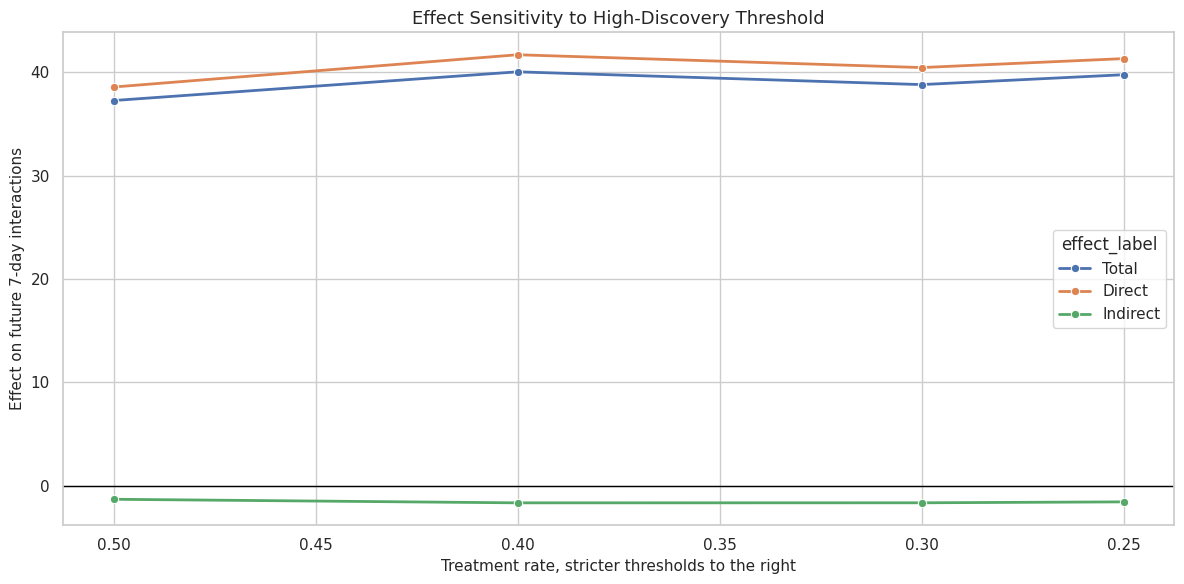

In [7]:
# Plot threshold sensitivity.
threshold_plot = threshold_results.melt(
    id_vars=["spec_name", "threshold_quantile", "treatment_rate"],
    value_vars=["gcomp_total_effect", "natural_direct_effect", "natural_indirect_effect"],
    var_name="effect_type",
    value_name="estimate",
)
threshold_plot["effect_label"] = threshold_plot["effect_type"].map(
    {
        "gcomp_total_effect": "Total",
        "natural_direct_effect": "Direct",
        "natural_indirect_effect": "Indirect",
    }
)
threshold_plot["threshold_label"] = threshold_plot["spec_name"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=threshold_plot,
    x="treatment_rate",
    y="estimate",
    hue="effect_label",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.invert_xaxis()
ax.set_title("Effect Sensitivity to High-Discovery Threshold")
ax.set_xlabel("Treatment rate, stricter thresholds to the right")
ax.set_ylabel("Effect on future 7-day interactions")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "17_threshold_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The threshold plot is a stability check. A jagged pattern would suggest that the result depends heavily on an arbitrary threshold. A smooth pattern is more reassuring. The decomposition is useful only if the pathway labels are kept clear, since direct, indirect, and total effects answer different operational questions.


### Robustness to Alternative Mediator Definitions

The baseline mediator is a composite satisfaction-depth score. This cell reruns the mediation decomposition with simpler mediator candidates. The purpose is to test whether the indirect pathway is a property of satisfaction broadly or only of one engineered score.

In [8]:
# Robustness to alternative mediator definitions.
mediator_rows = []
for mediator_label, mediator_col in mediator_candidates.items():
    result = estimate_binary_mediation_spec(
        analysis_panel,
        treatment_col=BASE_TREATMENT,
        mediator_col=mediator_col,
        outcome_col=PRIMARY_OUTCOME,
        numeric_cols=rich_numeric_covariates,
        categorical_cols=rich_categorical_covariates,
        spec_name=mediator_label,
        use_weights=True,
        include_interaction=True,
    )
    result["mediator_label"] = mediator_label
    mediator_rows.append(result)

mediator_results = pd.DataFrame(mediator_rows)

display(
    mediator_results[
        [
            "mediator_label",
            "mediator_col",
            "gcomp_total_effect",
            "natural_direct_effect",
            "natural_indirect_effect",
            "mediator_shift",
            "proportion_mediated",
            "mediator_model_r2",
        ]
    ].round(4)
)

,mediator_label,mediator_col,gcomp_total_effect,natural_direct_effect,natural_indirect_effect,mediator_shift,proportion_mediated,mediator_model_r2
0,composite_satisfaction_depth,M_satisfaction_depth,37.2781,38.5858,-1.3077,0.0231,-0.0351,0.4653
1,high_watch_ratio_share,high_satisfaction_share,37.2755,38.9900,-1.7145,0.0424,-0.0460,0.4301
2,valid_play_share,valid_play_share,37.3502,37.2221,0.1281,0.0065,0.0034,0.5762
3,average_satisfaction_score,avg_satisfaction_score,37.2560,38.5948,-1.3388,0.0174,-0.0359,0.4418
4,completion_or_rewatch_share,complete_or_rewatch_share,37.2665,38.7399,-1.4734,0.0289,-0.0395,0.4126


This is one of the most important checks. If all satisfaction mediators show small mediated pathways, the notebook 04 conclusion is more stable. If one mediator dominates, the final report should be precise about which satisfaction definition matters.

#### 9. Plot Mediator Sensitivity

This cell plots the direct and indirect estimates across mediator definitions. It keeps the total effect visible as a reference but focuses attention on the mediated pathway.

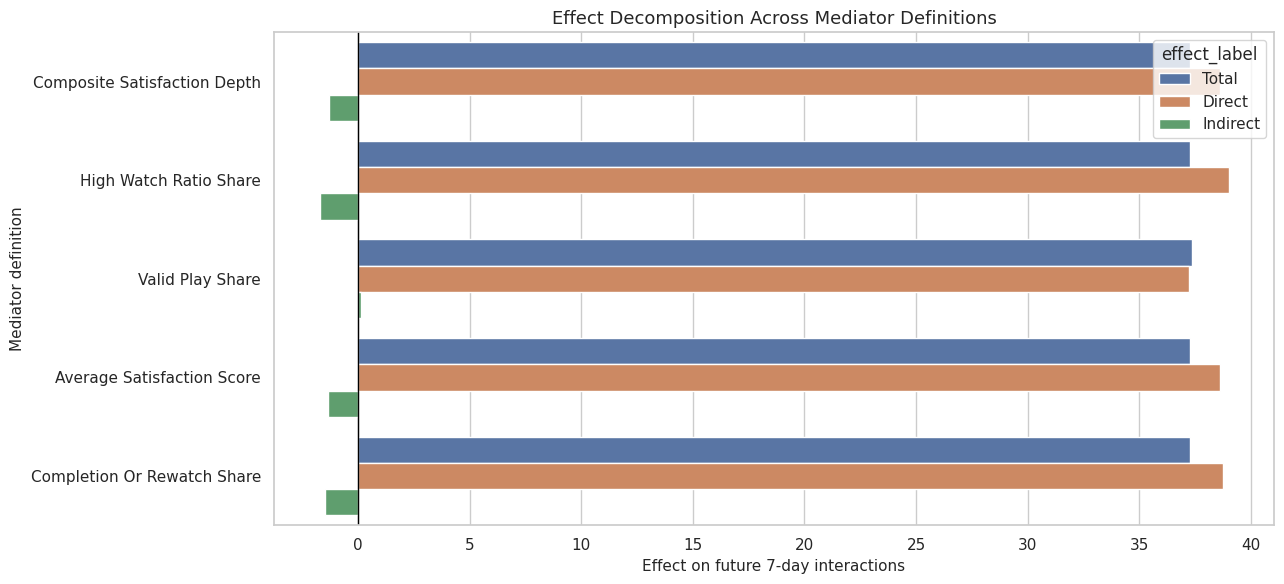

In [9]:
# Plot mediator sensitivity.
mediator_plot = mediator_results.melt(
    id_vars=["mediator_label"],
    value_vars=["gcomp_total_effect", "natural_direct_effect", "natural_indirect_effect"],
    var_name="effect_type",
    value_name="estimate",
)
mediator_plot["effect_label"] = mediator_plot["effect_type"].map(
    {
        "gcomp_total_effect": "Total",
        "natural_direct_effect": "Direct",
        "natural_indirect_effect": "Indirect",
    }
)
mediator_plot["mediator_label_clean"] = mediator_plot["mediator_label"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=mediator_plot,
    x="estimate",
    y="mediator_label_clean",
    hue="effect_label",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Effect Decomposition Across Mediator Definitions")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("Mediator definition")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "18_mediator_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The mediator plot makes the main sensitivity question visible. A consistent direct-effect bar with small indirect bars supports the idea that future interaction gains are not mainly routed through these satisfaction proxies.

### Robustness Across Outcomes

This cell repeats the baseline decomposition for future interactions, future active days, and future play hours. Notebook 04 already estimated these with bootstrap intervals; here we keep the point-estimate grid alongside the other robustness checks.

In [10]:
# Robustness across outcomes.
outcome_rows = []
for outcome_col in OUTCOME_COLUMNS:
    result = estimate_binary_mediation_spec(
        analysis_panel,
        treatment_col=BASE_TREATMENT,
        mediator_col=BASE_MEDIATOR,
        outcome_col=outcome_col,
        numeric_cols=rich_numeric_covariates,
        categorical_cols=rich_categorical_covariates,
        spec_name=f"baseline_{outcome_col}",
        use_weights=True,
        include_interaction=True,
    )
    outcome_rows.append(result)

outcome_results = pd.DataFrame(outcome_rows)

display(
    outcome_results[
        [
            "outcome_label",
            "gcomp_total_effect",
            "natural_direct_effect",
            "natural_indirect_effect",
            "mediator_shift",
            "relative_total_effect",
            "proportion_mediated",
        ]
    ].round(4)
)

,outcome_label,gcomp_total_effect,natural_direct_effect,natural_indirect_effect,mediator_shift,relative_total_effect,proportion_mediated
0,Future 7-day interactions,37.2781,38.5858,-1.3077,0.0231,0.1152,-0.0351
1,Future 7-day active days,0.0074,0.0021,0.0053,0.0231,0.0011,0.7175
2,Future 7-day play hours,0.0784,0.0739,0.0044,0.0231,0.1000,0.0562


Different outcomes answer different product questions. Future interactions measure volume, active days measure return frequency, and play hours measure attention. A result can be meaningful for one and weak for another.

### Sensitivity to Model Choices

This cell changes the model specification while holding the baseline treatment, mediator, and primary outcome fixed. It compares weighted versus unweighted regression, interaction versus no interaction, and rich versus simple controls.

In [11]:
# Sensitivity to model choices.
model_specs = [
    {
        "spec_name": "weighted_rich_with_interaction",
        "use_weights": True,
        "include_interaction": True,
        "numeric_cols": rich_numeric_covariates,
        "categorical_cols": rich_categorical_covariates,
    },
    {
        "spec_name": "unweighted_rich_with_interaction",
        "use_weights": False,
        "include_interaction": True,
        "numeric_cols": rich_numeric_covariates,
        "categorical_cols": rich_categorical_covariates,
    },
    {
        "spec_name": "weighted_rich_no_interaction",
        "use_weights": True,
        "include_interaction": False,
        "numeric_cols": rich_numeric_covariates,
        "categorical_cols": rich_categorical_covariates,
    },
    {
        "spec_name": "weighted_simple_with_interaction",
        "use_weights": True,
        "include_interaction": True,
        "numeric_cols": simple_numeric_covariates,
        "categorical_cols": simple_categorical_covariates,
    },
    {
        "spec_name": "unweighted_simple_no_interaction",
        "use_weights": False,
        "include_interaction": False,
        "numeric_cols": simple_numeric_covariates,
        "categorical_cols": simple_categorical_covariates,
    },
]

model_rows = []
for spec in model_specs:
    result = estimate_binary_mediation_spec(
        analysis_panel,
        treatment_col=BASE_TREATMENT,
        mediator_col=BASE_MEDIATOR,
        outcome_col=PRIMARY_OUTCOME,
        numeric_cols=spec["numeric_cols"],
        categorical_cols=spec["categorical_cols"],
        spec_name=spec["spec_name"],
        use_weights=spec["use_weights"],
        include_interaction=spec["include_interaction"],
    )
    result["control_set"] = "rich" if len(spec["numeric_cols"]) == len(rich_numeric_covariates) else "simple"
    model_rows.append(result)

model_sensitivity = pd.DataFrame(model_rows)

display(
    model_sensitivity[
        [
            "spec_name",
            "uses_weights",
            "include_interaction",
            "control_set",
            "gcomp_total_effect",
            "natural_direct_effect",
            "natural_indirect_effect",
            "mediator_shift",
            "relative_total_effect",
        ]
    ].round(4)
)

,spec_name,uses_weights,include_interaction,control_set,gcomp_total_effect,natural_direct_effect,natural_indirect_effect,mediator_shift,relative_total_effect
0,weighted_rich_with_interaction,True,True,rich,37.2781,38.5858,-1.3077,0.0231,0.1152
1,unweighted_rich_with_interaction,False,True,rich,36.4288,37.9141,-1.4853,0.0229,0.1130
2,weighted_rich_no_interaction,True,False,rich,37.3139,38.4311,-1.1172,0.0231,0.1153
3,weighted_simple_with_interaction,True,True,simple,37.6289,39.1871,-1.5581,0.0347,0.1169
4,unweighted_simple_no_interaction,False,False,simple,34.8085,35.7445,-0.9360,0.0320,0.1077


This table tells us whether the result is mostly a modeling artifact. A stable total effect across these rows is reassuring. A highly variable indirect effect would tell us to be cautious about strong claims about the mediator pathway.

#### 12. Plot Model-Specification Sensitivity

This cell visualizes the model-sensitivity table. It keeps direct and indirect pieces side by side for each model choice.

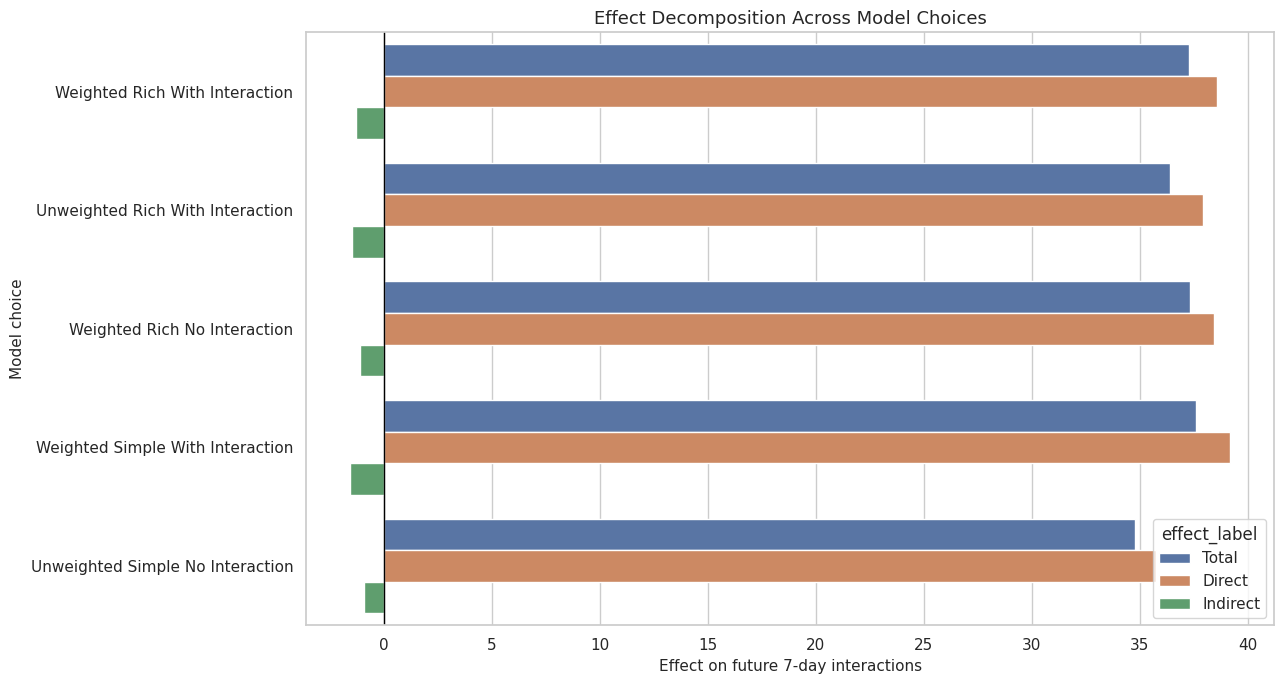

In [12]:
# Plot model-specification sensitivity.
model_plot = model_sensitivity.melt(
    id_vars=["spec_name"],
    value_vars=["gcomp_total_effect", "natural_direct_effect", "natural_indirect_effect"],
    var_name="effect_type",
    value_name="estimate",
)
model_plot["effect_label"] = model_plot["effect_type"].map(
    {
        "gcomp_total_effect": "Total",
        "natural_direct_effect": "Direct",
        "natural_indirect_effect": "Indirect",
    }
)
model_plot["spec_label"] = model_plot["spec_name"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(
    data=model_plot,
    x="estimate",
    y="spec_label",
    hue="effect_label",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Effect Decomposition Across Model Choices")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("Model choice")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "19_model_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The model-sensitivity plot is a compact way to see which part of the story is stable. In a strong result, the total effect should not depend on one narrow modeling choice.

#### 13. Continuous Discovery Score Check

The binary treatment is easy to explain, but it loses information. This cell treats `discovery_breadth_score` as continuous and estimates adjusted associations per 0.10 increase in discovery breadth. This is not a natural-effect decomposition; it is a separate dose-style sensitivity check.

In [13]:
# Continuous discovery score check.
def estimate_continuous_association(frame, score_col, target_col, numeric_cols, categorical_cols, scale=0.10):
    """
    Estimate an adjusted association for a continuous discovery score.
    
    Idea
    ----
    The helper supports sensitivity checks where discovery is treated as a score.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    score_col : object
        Project-specific input named `score_col` used by this helper.
    target_col : object
        Project-specific input named `target_col` used by this helper.
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    scale : object
        Whether to standardize the continuous score before modeling.
    
    Returns
    -------
    dict
        Adjusted coefficient and model diagnostics for the continuous score.
    """
    covariates = build_covariate_matrix(frame, numeric_cols, categorical_cols)
    score = frame[score_col].astype(float).to_numpy()
    target = frame[target_col].astype(float).to_numpy()
    design = covariates.copy()
    design.insert(0, score_col, score)
    model = LinearRegression().fit(design, target)
    coef = float(model.coef_[0])
    return {
        "target": target_col,
        "target_label": OUTCOME_LABELS.get(target_col, target_col),
        "score_col": score_col,
        "effect_per_0_10_score_increase": coef * scale,
        "raw_score_target_corr": frame[score_col].corr(frame[target_col], method="spearman"),
        "model_r2": model.score(design, target),
    }

continuous_rows = []
for target_col in OUTCOME_COLUMNS + [BASE_MEDIATOR]:
    continuous_rows.append(
        estimate_continuous_association(
            analysis_panel,
            DISCOVERY_SCORE,
            target_col,
            rich_numeric_covariates,
            rich_categorical_covariates,
        )
    )
continuous_sensitivity = pd.DataFrame(continuous_rows)

display(continuous_sensitivity.round(4))

,target,target_label,score_col,effect_per_0_10_score_increase,raw_score_target_corr,model_r2
0,Y_future_interactions,Future 7-day interactions,discovery_breadth_score,20.5518,0.5674,0.7220
1,Y_future_active_days,Future 7-day active days,discovery_breadth_score,0.0966,0.3980,0.5179
2,Y_future_play_hours,Future 7-day play hours,discovery_breadth_score,0.0447,0.5392,0.6999
3,M_satisfaction_depth,M_satisfaction_depth,discovery_breadth_score,0.0129,0.0930,0.4612


The continuous check asks whether more discovery breadth is associated with more future value without forcing a high-versus-low split. It should broadly agree with the binary result if the threshold is not doing all the work.

### Placebo-Style Checks

A dangerous pattern would be high discovery exposure strongly predicting variables that happened before the treatment day. This cell checks raw and adjusted relationships between high discovery and pre-period activity, prior satisfaction, prior discovery, and calendar day.

In [14]:
# Placebo-Style checks for pre-Period activity and calendar time.
placebo_targets = [
    "lag_1_interactions",
    "prior_3day_interactions",
    "prior_3day_high_satisfaction_share",
    "prior_3day_discovery_candidate_share",
    "calendar_day_index",
]

placebo_adjustment_numeric = [
    col
    for col in ["register_days", "follow_user_num", "fans_user_num", "friend_user_num", "is_lowactive_period", "is_live_streamer", "is_video_author"]
    if col in analysis_panel.columns
] + profile_onehot_covariates
placebo_adjustment_categorical = rich_categorical_covariates

placebo_rows = []
for target_col in placebo_targets:
    raw_high = analysis_panel.loc[analysis_panel[BASE_TREATMENT].eq(1), target_col].mean()
    raw_low = analysis_panel.loc[analysis_panel[BASE_TREATMENT].eq(0), target_col].mean()

    numeric_cols = [col for col in placebo_adjustment_numeric if col != target_col]
    categorical_cols = [col for col in placebo_adjustment_categorical if col != target_col]
    covariates = build_covariate_matrix(analysis_panel, numeric_cols, categorical_cols)
    design = covariates.copy()
    design.insert(0, BASE_TREATMENT, analysis_panel[BASE_TREATMENT].astype(float).to_numpy())
    model = LinearRegression().fit(design, analysis_panel[target_col].astype(float).to_numpy())
    adjusted_difference = float(model.coef_[0])

    placebo_rows.append(
        {
            "placebo_target": target_col,
            "raw_high_minus_lower": raw_high - raw_low,
            "adjusted_difference": adjusted_difference,
            "target_mean": analysis_panel[target_col].mean(),
            "relative_raw_difference": (raw_high - raw_low) / analysis_panel[target_col].mean() if not np.isclose(analysis_panel[target_col].mean(), 0) else np.nan,
        }
    )

placebo_checks = pd.DataFrame(placebo_rows)

display(placebo_checks.round(4))

,placebo_target,raw_high_minus_lower,adjusted_difference,target_mean,relative_raw_difference
0,lag_1_interactions,18.3176,18.3670,51.0316,0.3589
1,prior_3day_interactions,49.0163,49.1383,152.5819,0.3212
2,prior_3day_high_satisfaction_share,-0.0321,-0.0363,1.3416,-0.0239
3,prior_3day_discovery_candidate_share,0.3502,0.3493,1.0706,0.3271
4,calendar_day_index,-15.6133,-15.6544,30.7969,-0.5070


The placebo-style checks are expected to show some pre-period differences because discovery exposure is not randomized. The point is to make that imbalance visible and connect it back to the need for adjustment and sensitivity analysis.

#### 15. Plot Placebo-Style Checks

This cell plots raw and adjusted pre-period differences. Large pre-period differences warn that observational logs require careful adjustment and modest claims.

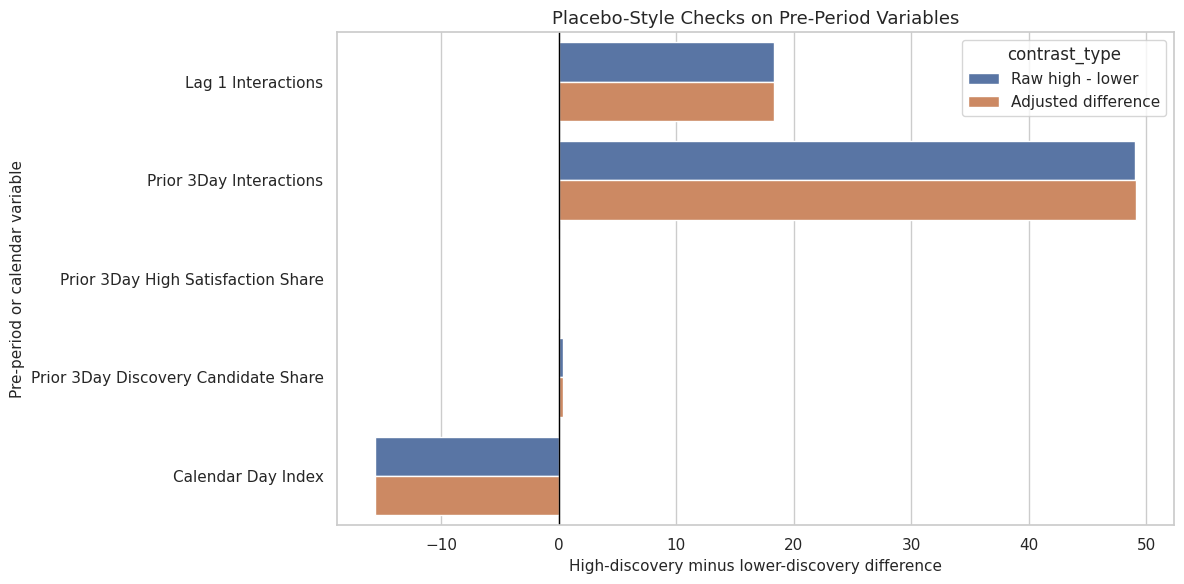

In [15]:
placebo_plot = placebo_checks.melt(
    id_vars=["placebo_target"],
    value_vars=["raw_high_minus_lower", "adjusted_difference"],
    var_name="contrast_type",
    value_name="difference",
)
placebo_plot["contrast_type"] = placebo_plot["contrast_type"].map(
    {
        "raw_high_minus_lower": "Raw high - lower",
        "adjusted_difference": "Adjusted difference",
    }
)
placebo_plot["target_label"] = placebo_plot["placebo_target"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=placebo_plot, x="difference", y="target_label", hue="contrast_type", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Placebo-Style Checks on Pre-Period Variables")
ax.set_xlabel("High-discovery minus lower-discovery difference")
ax.set_ylabel("Pre-period or calendar variable")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "20_placebo_preperiod_checks.png", dpi=160, bbox_inches="tight")
plt.show()

This plot helps communicate why the earlier balance and propensity diagnostics matter. The treatment is observational, so a final report should emphasize adjusted estimates and limitations.

### Summarize Robustness Patterns

This cell creates a compact summary across robustness families. It focuses on whether the total effect stays positive and whether the indirect effect remains small relative to the direct effect.

In [16]:
robustness_families = []

for family_name, frame in [
    ("threshold_sensitivity", threshold_results),
    ("mediator_sensitivity", mediator_results),
    ("model_sensitivity", model_sensitivity),
    ("outcome_sensitivity", outcome_results.query("outcome == @PRIMARY_OUTCOME")),
]:
    robustness_families.append(
        {
            "robustness_family": family_name,
            "specifications": len(frame),
            "total_effect_min": frame["gcomp_total_effect"].min(),
            "total_effect_max": frame["gcomp_total_effect"].max(),
            "total_effect_share_positive": (frame["gcomp_total_effect"] > 0).mean(),
            "indirect_effect_min": frame["natural_indirect_effect"].min(),
            "indirect_effect_max": frame["natural_indirect_effect"].max(),
            "indirect_effect_share_positive": (frame["natural_indirect_effect"] > 0).mean(),
            "median_abs_indirect_to_total_ratio": np.nanmedian(
                np.abs(frame["natural_indirect_effect"] / frame["gcomp_total_effect"].replace(0, np.nan))
            ),
        }
    )

robustness_summary = pd.DataFrame(robustness_families)

display(robustness_summary.round(4))

,robustness_family,specifications,total_effect_min,total_effect_max,total_effect_share_positive,indirect_effect_min,indirect_effect_max,indirect_effect_share_positive,median_abs_indirect_to_total_ratio
0,threshold_sensitivity,4,37.2781,40.0555,1.0,-1.6532,-1.3077,0.0,0.0402
1,mediator_sensitivity,5,37.2560,37.3502,1.0,-1.7145,0.1281,0.2,0.0359
2,model_sensitivity,5,34.8085,37.6289,1.0,-1.5581,-0.9360,0.0,0.0351
3,outcome_sensitivity,1,37.2781,37.2781,1.0,-1.3077,-1.3077,0.0,0.0351


This summary turns many model runs into a few takeaways. The strongest claim is the one that remains stable across robustness families. The weaker claim is the one that moves around or depends on a specific metric definition.

### Limitations Table

This cell writes a limitations table for the final report. These are not flaws to hide. They are the boundaries that make the analysis honest and more believable.

In [17]:
# Prepare limitations table.
limitations = pd.DataFrame(
    [
        {
            "limitation": "observational_recommendation_logs",
            "why_it_matters": "High-discovery exposure was not randomized, so user preferences and recommender selection can confound estimates.",
            "mitigation_in_this_work": "Used pre-treatment history/profile controls, propensity diagnostics, and weighted sensitivity checks.",
            "remaining_risk": "Unobserved ranking-system state and user intent can still bias estimates.",
        },
        {
            "limitation": "mediator_outcome_confounding",
            "why_it_matters": "Satisfaction depth and future engagement may share unobserved causes.",
            "mitigation_in_this_work": "Checked residual mediator-outcome relationships and compared multiple mediator definitions.",
            "remaining_risk": "Natural direct and indirect effects rely on strong mediator assumptions.",
        },
        {
            "limitation": "satisfaction_proxy_measurement",
            "why_it_matters": "Watch ratio and valid play are proxies, not direct surveys of satisfaction.",
            "mitigation_in_this_work": "Compared composite satisfaction, high watch ratio, valid play, average score, and completion-style mediators.",
            "remaining_risk": "The chosen proxies may miss frustration, novelty value, or long-run satisfaction.",
        },
        {
            "limitation": "active_day_sample_selection",
            "why_it_matters": "The analysis conditions on active user-days, so it does not study days with no observed interactions.",
            "mitigation_in_this_work": "Defined the estimand clearly for active days and reported active-day alternate outcomes.",
            "remaining_risk": "Results may not generalize to dormant users or cold-start retention decisions.",
        },
        {
            "limitation": "calendar_and_history_imbalance",
            "why_it_matters": "High discovery days differ from lower discovery days in time and recent behavior.",
            "mitigation_in_this_work": "Included calendar/history controls and showed placebo-style pre-period checks.",
            "remaining_risk": "Residual time-varying confounding can remain after observed adjustment.",
        },
    ]
)

display(limitations)

,limitation,why_it_matters,mitigation_in_this_work,remaining_risk
0,observational_recommendation_logs,"High-discovery exposure was not randomized, so user preferences and recommender selection can confound estimates.","Used pre-treatment history/profile controls, propensity diagnostics, and weighted sensitivity checks.",Unobserved ranking-system state and user intent can still bias estimates.
1,mediator_outcome_confounding,Satisfaction depth and future engagement may share unobserved causes.,Checked residual mediator-outcome relationships and compared multiple mediator definitions.,Natural direct and indirect effects rely on strong mediator assumptions.
2,satisfaction_proxy_measurement,"Watch ratio and valid play are proxies, not direct surveys of satisfaction.","Compared composite satisfaction, high watch ratio, valid play, average score, and completion-style mediators.","The chosen proxies may miss frustration, novelty value, or long-run satisfaction."
3,active_day_sample_selection,"The analysis conditions on active user-days, so it does not study days with no observed interactions.",Defined the estimand clearly for active days and reported active-day alternate outcomes.,Results may not generalize to dormant users or cold-start retention decisions.
4,calendar_and_history_imbalance,High discovery days differ from lower discovery days in time and recent behavior.,Included calendar/history controls and showed placebo-style pre-period checks.,Residual time-varying confounding can remain after observed adjustment.


The limitations table gives the final report a professional tone. It shows that the analysis is careful about where the evidence is strong and where it remains assumption-dependent.

#### 18. Save Robustness Outputs

This cell saves all robustness tables to `data/processed` and mirrors the main tables into the notebook writeup folder.

In [18]:
# Save robustness outputs.
threshold_results.to_csv(THRESHOLD_OUTPUT, index=False)
mediator_results.to_csv(MEDIATOR_OUTPUT, index=False)
model_sensitivity.to_csv(MODEL_SENSITIVITY_OUTPUT, index=False)
continuous_sensitivity.to_csv(CONTINUOUS_OUTPUT, index=False)
placebo_checks.to_csv(PLACEBO_OUTPUT, index=False)
robustness_summary.to_csv(ROBUSTNESS_SUMMARY_OUTPUT, index=False)
limitations.to_csv(LIMITATIONS_OUTPUT, index=False)

threshold_results.to_csv(TABLE_DIR / "robustness_thresholds.csv", index=False)
mediator_results.to_csv(TABLE_DIR / "robustness_mediators.csv", index=False)
model_sensitivity.to_csv(TABLE_DIR / "model_sensitivity.csv", index=False)
continuous_sensitivity.to_csv(TABLE_DIR / "continuous_score_sensitivity.csv", index=False)
placebo_checks.to_csv(TABLE_DIR / "placebo_checks.csv", index=False)
robustness_summary.to_csv(TABLE_DIR / "robustness_summary.csv", index=False)
limitations.to_csv(TABLE_DIR / "limitations.csv", index=False)

saved_outputs = pd.DataFrame(
    {
        "artifact": [
            "threshold_robustness",
            "mediator_robustness",
            "model_sensitivity",
            "continuous_score_sensitivity",
            "placebo_checks",
            "robustness_summary",
            "limitations",
        ],
        "path": [
            str(THRESHOLD_OUTPUT),
            str(MEDIATOR_OUTPUT),
            str(MODEL_SENSITIVITY_OUTPUT),
            str(CONTINUOUS_OUTPUT),
            str(PLACEBO_OUTPUT),
            str(ROBUSTNESS_SUMMARY_OUTPUT),
            str(LIMITATIONS_OUTPUT),
        ],
    }
)

display(saved_outputs)

,artifact,path
0,threshold_robustness,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_robustness_thresholds.csv
1,mediator_robustness,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_robustness_mediators.csv
2,model_sensitivity,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_model_sensitivity.csv
3,continuous_score_sensitivity,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_continuous_score_sensitivity.csv
4,placebo_checks,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_placebo_checks.csv
5,robustness_summary,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_robustness_summary.csv
6,limitations,/home/apex/Documents/portfolio/data/processed/kuairec_discovery_quality_limitations.csv


The saved outputs make this robustness work reusable. A final report can pull directly from these tables without recomputing the sensitivity grid. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


### Takeaways and Next Step

This notebook stress-tested the mediation result from several angles:

- The total future-interaction effect is checked across stricter discovery thresholds.
- The mediated pathway is checked across several satisfaction proxy definitions.
- The result is compared across future interactions, active days, and play hours.
- Model choices are varied through weighting, interactions, and control-set size.
- Placebo-style checks make pre-period imbalance visible.
- The limitations table records what the observational design cannot fully solve.

The next notebook should be the final report and figures notebook for this discovery-quality mediation project. It should turn the evidence into a concise report-ready narrative with the key tables, plots, and caveats.